# Plot TapSEGNN results 

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import os 
import sys 
import joblib 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from utils.ppnet_utils import initialize_network, custom_se
from utils.gen_utils import load_config
from utils.load_data_utils import load_sampled_input_data

config = load_config('config.yaml')

In [2]:
# initialise the network and use the same data to solve wls and GAT for the SE 
net = initialize_network(net_name='MVO',
                         load_std=config['data']['load_std'])

num_samples = config['data']['num_samples']
num_buses = len(net.bus)

# use same data for all: wls, gat, tapsegnn
sampled_input_data = load_sampled_input_data(sc_type=config['data']['scenario_type'], 
                                                   net=net, 
                                                   num_samples=config['data']['num_samples'], 
                                                   noise=config['data']['noise'])
# sampled_input_data = joblib.load(parent_dir + f"/data/samples_16384.joblib")

Transformer Indices for MVO are available from [0,141] 

Number of Trafos = 143 
 
Network: MVO is selected 

Net MVO has 320 nodes and 318 edges. 

Filling nan as 0 in tap_pos, tap_neutral, tap_step_degree
Selecting all the MV/LV transformers in the network 

>>> Using relative noise of 1.0% on voltage and 5.0% on power measurements.
Scaling inputs...
Number of V, P measurements 337 out of 640

Number of P_to, Q_to, P_from, Q_from measurements 163 out of 324

Sparsity of PV measurements at buses = 0.5%
Sparsity of P+ measurements at branches = 0.5


Please ignore sparsity comments above. 

## Compute WLS RMSE and bus-level absolute errors

In [3]:
import logging
from tqdm import tqdm

# Disable pandapower state estimation debug messages
logging.getLogger('pandapower.estimation.state_estimation').setLevel(logging.WARNING)

# Or disable all pandapower debug messages
logging.getLogger('pandapower').setLevel(logging.WARNING)

# WLS estimates
wls_est_v = np.zeros((num_buses, num_samples))
wls_est_a = np.zeros((num_buses, num_samples))
label_v_pfr = np.zeros((num_buses, num_samples))
label_a_pfr = np.zeros((num_buses, num_samples))

for sample_id in tqdm(range(5)): # not all, very similar results.
    label_v_pfr[:, sample_id] = sampled_input_data['res_bus_vm_pu'][:,sample_id]
    label_a_pfr[:, sample_id] = sampled_input_data['res_bus_va_deg'][:,sample_id]
    
    pfr_dict = {'vm_pfr': sampled_input_data['res_bus_vm_pu'][:,sample_id], 
                'p_pfr': sampled_input_data['res_bus_p_mw'][:,sample_id],
                'p_pfr_line': sampled_input_data['edge_p_pfr_edge'][:,sample_id],
                'q_pfr': sampled_input_data['res_bus_q_mvar'][:,sample_id]}
    
    net_meas = custom_se(net=net, pfr_dict=pfr_dict, se_iter=20) 
                         
    wls_est_v[:, sample_id] = net_meas.res_bus_est.vm_pu.values 
    wls_est_a[:, sample_id] = net_meas.res_bus_est.va_degree.values 


100%|██████████| 5/5 [00:04<00:00,  1.03it/s]


In [4]:
# RMSE over all the buses 
all_bus_net_rmse_v_wls = np.sqrt(np.mean((label_v_pfr[:,0] - wls_est_v[:,0])**2))
all_bus_net_rmse_a_wls = np.sqrt(np.mean((label_a_pfr[:,0] - wls_est_a[:,0])**2))

# Absolute error across all buses 
abs_err_v_wls = np.abs(label_v_pfr[:,0] - wls_est_v[:,0])
abs_err_a_wls = np.abs(label_a_pfr[:,0] - wls_est_a[:,0])

## Make dataset for GAT and TapSEGNN training 

In [5]:
import torch
from utils.model_utils import initialize_model, get_eval_results
from src.dataset.custom_dataset import NodeEdgeTapDatasetV2
from utils.gen_utils import dataset_splitter
from training.trainer import trainer

device='cpu'

dataset = NodeEdgeTapDatasetV2(model_name=config['model']['name'], sampled_input_data=sampled_input_data)

all_loaders, plot_loader = dataset_splitter(dataset,
                                            batch_size=config['loader']['batch_size'],
                                            split_list=config['loader']['split_list'])

Dataset for NEGATRegressor selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...



## Train TapSEGNN: NEGATRegressor is the core model for SE

In [6]:
model = initialize_model(model_name=config['model']['name'],
                        dataset=dataset,
                        node_out_features=config['model']['node_out_features'],
                        list_node_hidden_features=config['model']['list_node_hidden_features'],
                        k_hop_node=config['model']['k_hop_node'],
                        edge_out_features=config['model']['edge_out_features'], 
                        list_edge_hidden_features=config['model']['list_edge_hidden_features'],
                        k_hop_edge=config['model']['k_hop_edge'],
                        trafo_hop=config['model']['trafo_hop'],
                        edge_index_list=sampled_input_data['edge_index'],
                        gat_out_features=config['model']['gat_out_features'],
                        gat_head=config['model']['gat_head'],
                        bias=config['model']['bias'], 
                        normalize=config['model']['normalize'], 
                        device=device,
                        ).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model}: {total_params}')

optimizer = torch.optim.Adam(model.parameters(),
                            lr=config['training']['lr'], 
                            weight_decay=config['training']['weight_decay'])
        
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    factor=0.5,        # Gentler: 0.01→0.005→0.0025
    patience=10,       # Wait 50 epochs before reducing
    min_lr=config['training']['schedular_min_lr'],       # Lower floor for more room
    threshold=1e-4,    # Only reduce if improvement < 0.0001
    cooldown=5        # Wait 20 epochs after reduction
)

all_losses = trainer(model=model, 
                    train_loader=all_loaders[0], 
                    val_loader=all_loaders[1], 
                    test_loader=all_loaders[2], 
                    optimizer=optimizer,
                    schedular=scheduler,
                    num_epoch=config['training']['num_epochs'],
                    early_stopping=config['training']['early_stopping'],
                    val_patience=config['training']['val_patience'], 
                    tap_weight=config['training']['loss_tap_weight'],
                    angle_weight=config['training']['angle_weight'], 
                    device=device)

results_tapse, pred_se_va_tapse, label_se_va_tapse  = get_eval_results(test_loader=all_loaders[2],
                                tap_weight=config['training']['loss_tap_weight'], 
                            trained_model=model, 
                            scaler=sampled_input_data['scaler_y_label'], 
                            output_pred_va=True)

Total number of parameters of model NEGATRegressor(
  (node_layers): ModuleList(
    (0): TAGConv(2, 64, K=3)
  )
  (fc_node): Linear(in_features=64, out_features=32, bias=True)
  (edge_layers): ModuleList(
    (0): ModuleList(
      (0-1): 2 x TAGConv(6, 128, K=1)
    )
  )
  (edge_biases): ParameterList(  (0): Parameter containing: [torch.float32 of size 128])
  (fc_edge): Linear(in_features=128, out_features=64, bias=True)
  (gatconv): GATConv(32, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
): 18434


  1%|          | 3/500 [00:00<00:19, 24.89it/s]

At epoch: 0, 	 training loss: 3.885e+05,                     	 validation loss: 2.169e+05 	 lr: 1.00e-02 	 grad_norm: 1.048e+06


  6%|▌         | 31/500 [00:01<00:16, 28.67it/s]

At epoch: 25, 	 training loss: 6.004e+04,                     	 validation loss: 5.409e+04 	 lr: 1.00e-02 	 grad_norm: 9.782e+04


...

At epoch: 450, 	 training loss: 2.659e+04,                     	 validation loss: 1.855e+04 	 lr: 1.00e-06 	 grad_norm: 1.199e+04


 96%|█████████▌| 480/500 [00:16<00:00, 32.53it/s]

At epoch: 475, 	 training loss: 2.656e+04,                     	 validation loss: 1.855e+04 	 lr: 1.00e-06 	 grad_norm: 1.094e+04


100%|██████████| 500/500 [00:16<00:00, 30.07it/s]

Model training took 16.627 seconds.
Test Loss of the resulting model is 1.85796191e+04
Calculating results for StandardScaled Voltage and Angles.


In [7]:
num_graphs_t = int(pred_se_va_tapse.shape[0]/num_buses)

pred_se_va_tapse_rs = torch.reshape(pred_se_va_tapse, (num_graphs_t,num_buses,-1))
label_se_va_tapse_rs = torch.reshape(label_se_va_tapse, (num_graphs_t,num_buses,-1))

# for a single graph
all_bus_net_rmse_v_tap = torch.sqrt(torch.mean((pred_se_va_tapse_rs[0,:,0] - label_se_va_tapse_rs[0,:,0])**2))
all_bus_net_rmse_a_tap = torch.sqrt(torch.mean((pred_se_va_tapse_rs[0,:,1] - label_se_va_tapse_rs[0,:,1])**2))

abs_err_v_tap =  torch.abs(pred_se_va_tapse_rs[0,:,0] - label_se_va_tapse_rs[0,:,0])
abs_err_a_tap = torch.abs(pred_se_va_tapse_rs[0,:,1] - label_se_va_tapse_rs[0,:,1])

In [8]:
# first_epochs = 500
# list_mean_acc_all_taps = np.array(all_losses[4][:first_epochs])
# list_mean_acc_all_taps[65] = list_mean_acc_all_taps[66]

DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=11.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-BoldOblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 8.835
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/.venv/lib/python3.11/site-packages/matplotlib/m

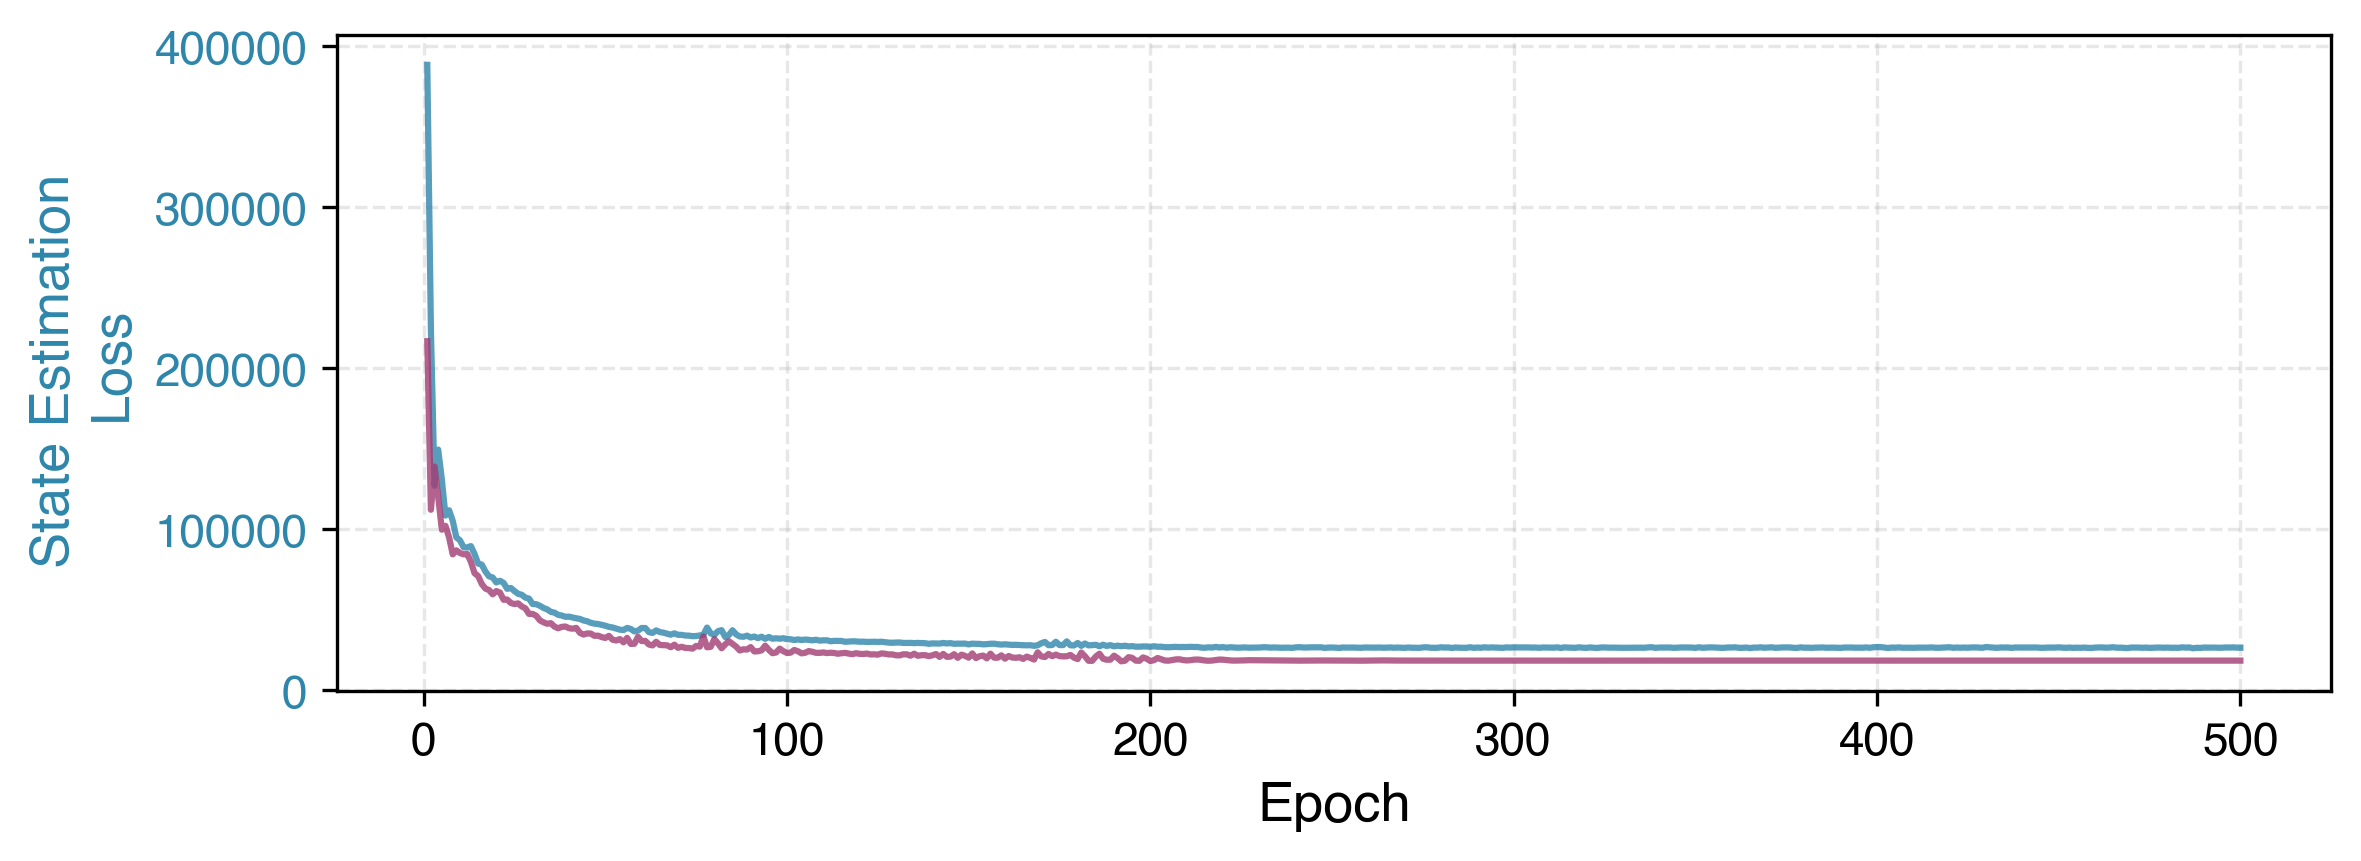

In [9]:
# Training dynamics of TapSEGNN
other_losses = all_losses[5]
se_train_losses = other_losses['se_train_losses']
se_val_losses = other_losses['se_val_losses']
# se_train_losses = all_losses[0][:]
# se_val_losses = all_losses[1]
# list_mean_acc_all_taps = all_losses[4]

%matplotlib inline
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with two subplots
fig, ax1 = plt.subplots(figsize=(8, 3))

# Plot losses on left y-axis
epochs = range(1, len(se_train_losses) + 1)
line1 = ax1.plot(epochs, se_train_losses, label='Training Loss', 
                 color='#2E86AB', linewidth=1.5, alpha=0.8)
line2 = ax1.plot(epochs, se_val_losses, label='Validation Loss', 
                 color='#A23B72', linewidth=1.5, alpha=0.8)

# ax1.set_yscale('log')
ax1.set_xlabel('Epoch', fontweight='semibold')
ax1.set_ylabel('State Estimation \nLoss', fontweight='semibold', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# Create second y-axis for tap accuracy
# ax2 = ax1.twinx()
# line3 = ax2.plot(epochs, list_mean_acc_all_taps, label='Tap Accuracy', 
#                  color='#F18F01', linewidth=1.5, alpha=0.8)

# ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3%}'))
# ax2.set_ylabel('Tap Prediction \nAccuracy', fontweight='semibold', color='#F18F01')
# ax2.tick_params(axis='y', labelcolor='#F18F01')
# ax2.set_ylim([0.80,1.01])

# # Combine legends
# lines = line1 + line2 + line3
# labels = [l.get_label() for l in lines]
# ax2.legend(lines, labels, loc='center right', framealpha=0.0, 
#            edgecolor='gray', fancybox=False)
# ax2.set_yscale('log')

# Set title
# ax1.set_title('TapSEGNN Training Dynamics', pad=15)

# Adjust layout
fig.tight_layout()

fig.savefig('FIG_TapSE_training_dynamics.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Train GAT 

In [10]:
model_GAT = initialize_model(model_name="GATRegressor",
                            dataset=dataset,
                            node_out_features=config['model']['node_out_features'],
                            list_node_hidden_features=config['model']['list_node_hidden_features'],
                            k_hop_node=config['model']['k_hop_node'],
                            edge_out_features=config['model']['edge_out_features'], 
                            list_edge_hidden_features=config['model']['list_edge_hidden_features'],
                            k_hop_edge=config['model']['k_hop_edge'],
                            trafo_hop=config['model']['trafo_hop'],
                            edge_index_list=sampled_input_data['edge_index'],
                            gat_out_features=config['model']['gat_out_features'],
                            gat_head=config['model']['gat_head'],
                            bias=config['model']['bias'], 
                            normalize=config['model']['normalize'], 
                            device=device,  
                            ).to(device)    

total_params = sum(p.numel() for p in model_GAT.parameters() if p.requires_grad)

print(f'Total number of parameters of model {model_GAT}: {total_params}')

optimizer_GAT = torch.optim.Adam(model_GAT.parameters(),lr=config['training']['lr'], weight_decay=config['training']['weight_decay'])

schedular_GAT = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_GAT, 
                                                    mode='min',
                                                    factor=0.1, 
                                                    min_lr=config['training']['schedular_min_lr'])

# GAT 
all_losses_GAT = trainer(model=model_GAT, 
                    train_loader=all_loaders[0], 
                    val_loader=all_loaders[1], 
                    test_loader=all_loaders[2], 
                    optimizer=optimizer_GAT,
                    schedular=schedular_GAT,
                    num_epoch=config['training']['num_epochs'],
                    early_stopping=True,
                    val_patience=config['training']['val_patience'],
                    angle_weight=config['training']['angle_weight'],  
                    device=device)

results, pred_se_va, label_se_va = get_eval_results(test_loader=all_loaders[2],
                                tap_weight=config['training']['loss_tap_weight'], 
                                trained_model=model_GAT, 
                                scaler=sampled_input_data['scaler_y_label'], 
                                output_pred_va=True)

Total number of parameters of model GATRegressor(
  (gatconv): GATConv(2, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
): 450


  2%|▏         | 8/500 [00:00<00:06, 75.37it/s]

At epoch: 0, 	 training loss: 1.009e+05,                     	 validation loss: 1.000e+05 	 lr: 1.00e-02 	 grad_norm: 2.560e+04


  8%|▊         | 40/500 [00:00<00:06, 75.53it/s]

At epoch: 25, 	 training loss: 7.911e+04,                     	 validation loss: 7.805e+04 	 lr: 1.00e-02 	 grad_norm: 7.386e+03


...

At epoch: 150, 	 training loss: 7.725e+04,                     	 validation loss: 7.636e+04 	 lr: 1.00e-02 	 grad_norm: 2.089e+03


 36%|███▋      | 182/500 [00:02<00:04, 69.55it/s]

At epoch: 175, 	 training loss: 7.723e+04,                     	 validation loss: 7.632e+04 	 lr: 1.00e-04 	 grad_norm: 5.393e+03


 41%|████      | 203/500 [00:02<00:04, 68.82it/s]

At epoch: 200, 	 training loss: 7.723e+04,                     	 validation loss: 7.632e+04 	 lr: 1.00e-05 	 grad_norm: 1.081e+03
Early Stopping at epoch 203...
Model training took 2.951 seconds.
Test Loss of the resulting model is 7.59206641e+04
Calculating results for StandardScaled Voltage and Angles.


In [11]:
num_graphs = int(pred_se_va.shape[0]/num_buses)

pred_se_va_rs = torch.reshape(pred_se_va, (num_graphs,num_buses,-1))
label_se_va_rs = torch.reshape(label_se_va, (num_graphs,num_buses,-1))

# for a single graph
all_bus_net_rmse_v_gat = torch.sqrt(torch.mean((pred_se_va_rs[0,:,0] - label_se_va_rs[0,:,0])**2))
all_bus_net_rmse_a_gat = torch.sqrt(torch.mean((pred_se_va_rs[0,:,1] - label_se_va_rs[0,:,1])**2))

abs_err_v_gat =  torch.abs(pred_se_va_rs[0,:,0] - label_se_va_rs[0,:,0])
abs_err_a_gat = torch.abs(pred_se_va_rs[0,:,1] - label_se_va_rs[0,:,1])

## Plot Result

DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=semibold:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-BoldOblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 8.645
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.24
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/.venv/lib/python3.11/site-packages/matplotlib

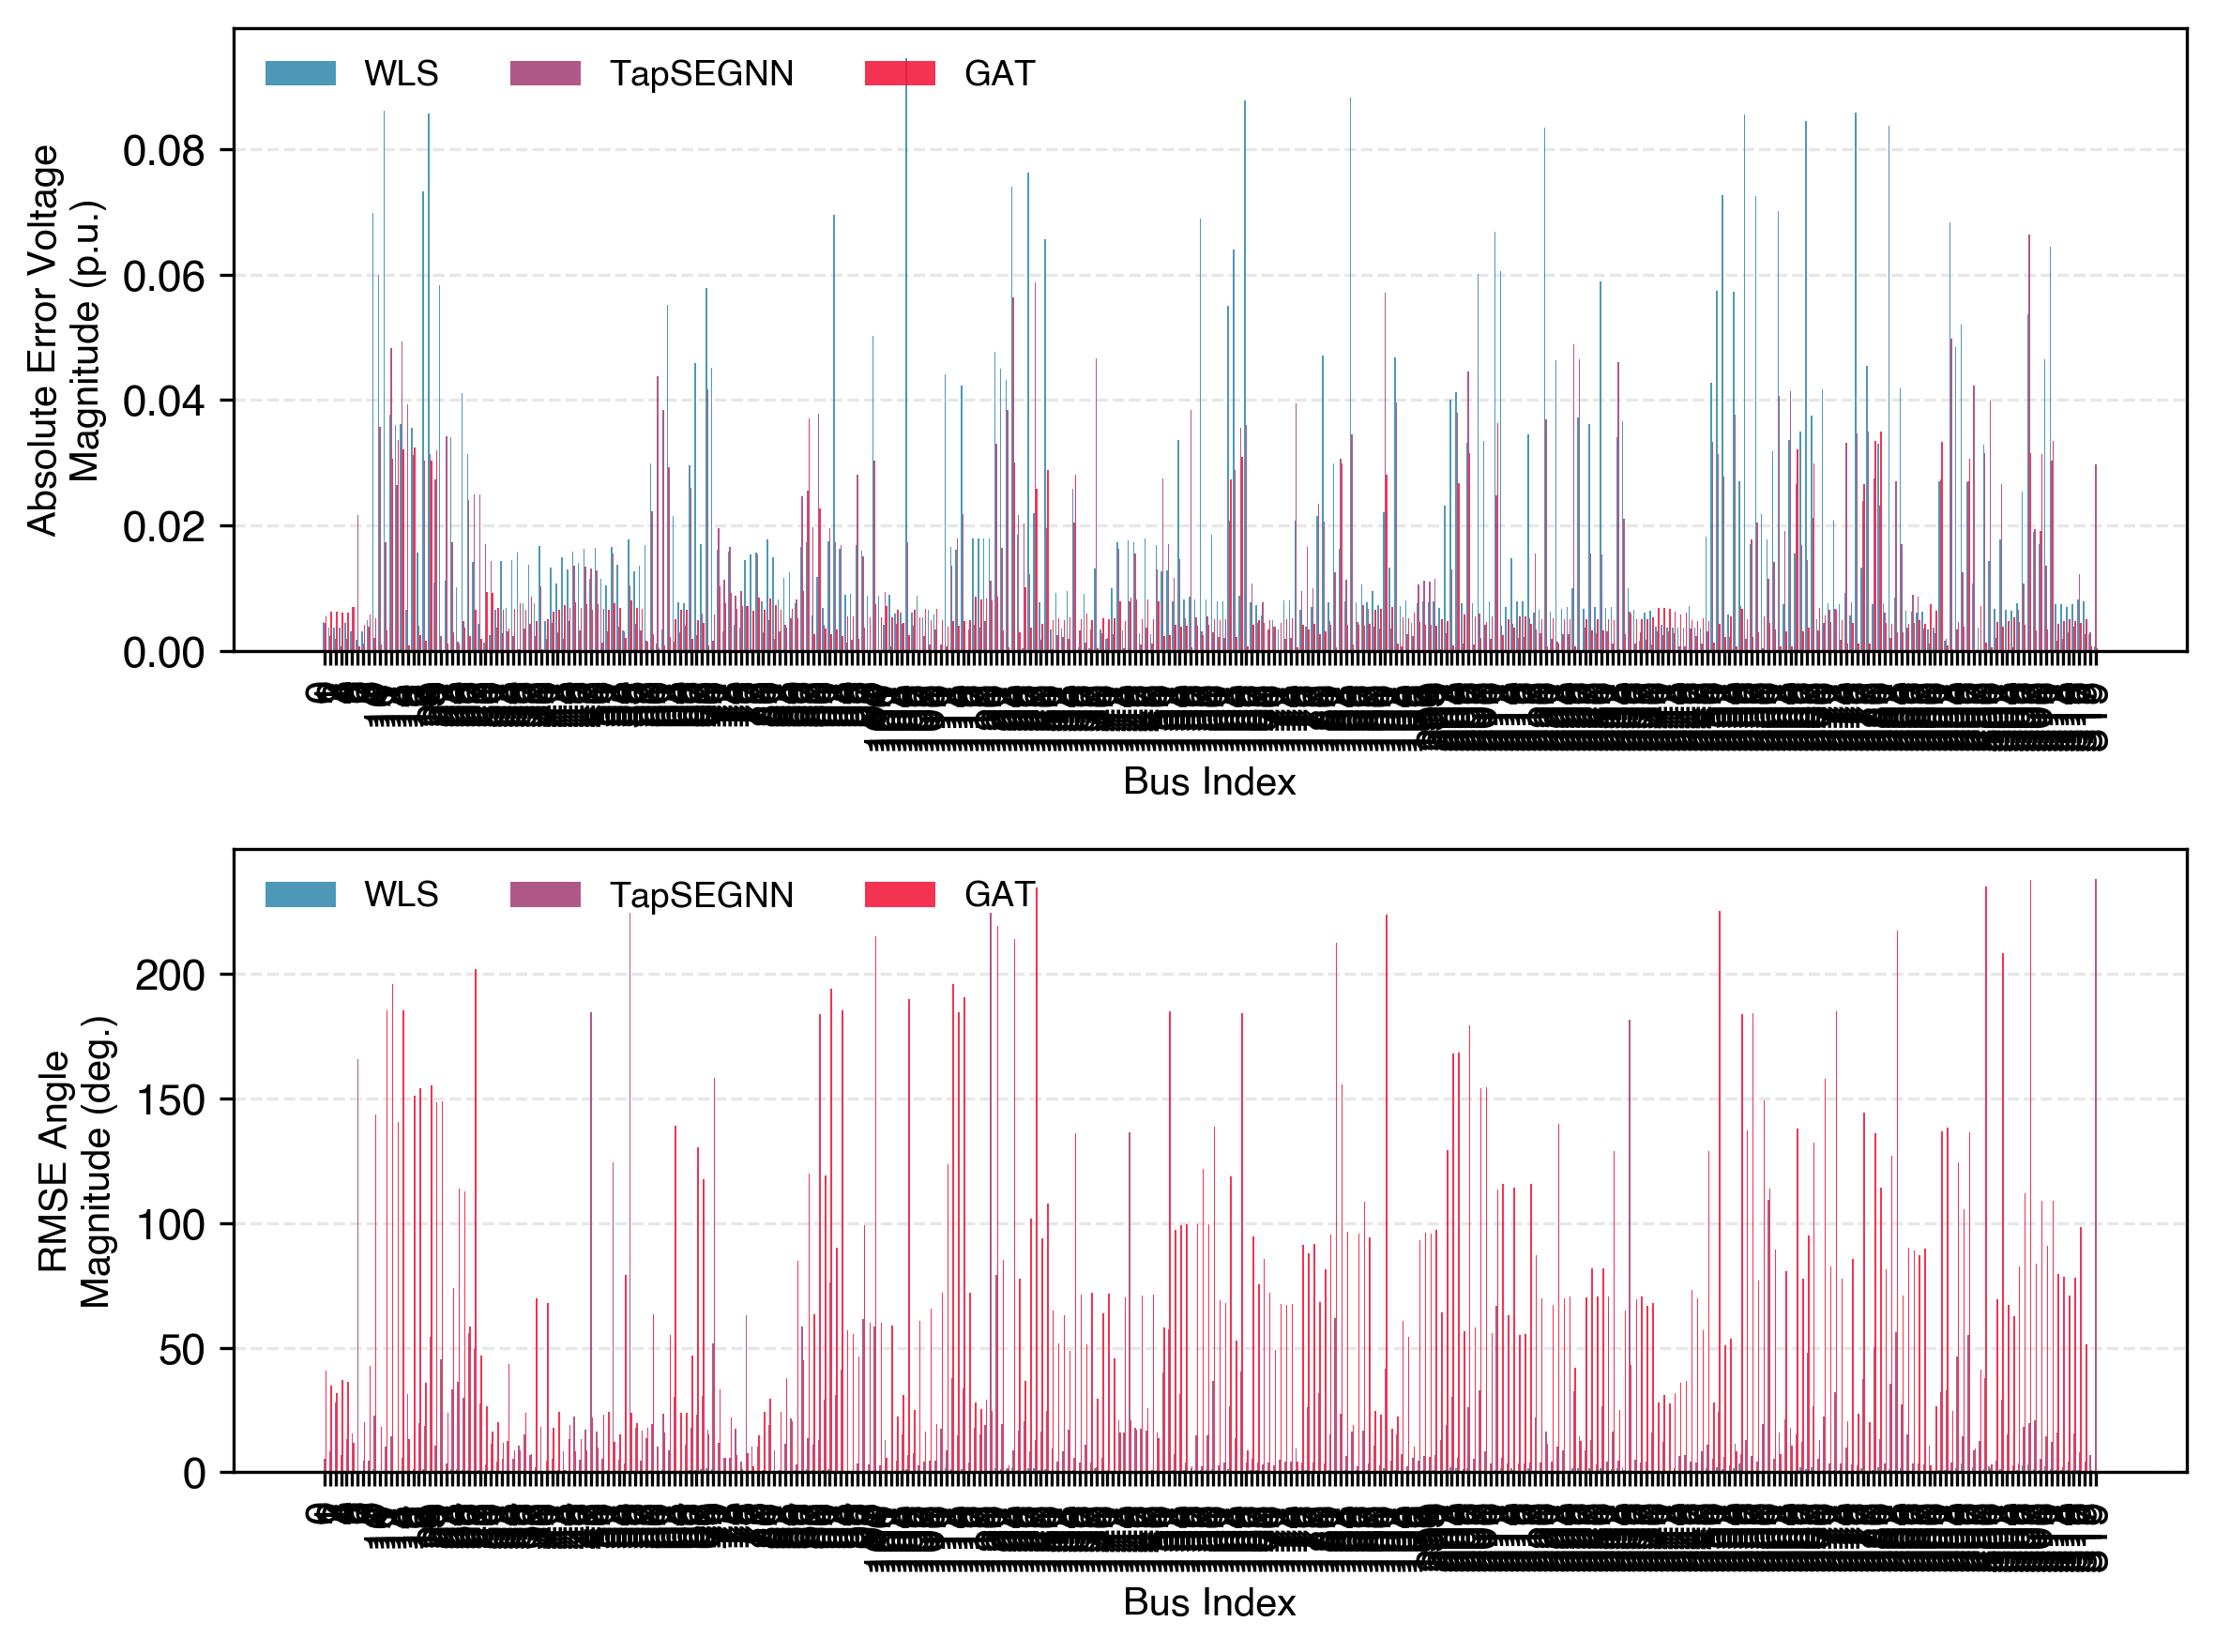

In [12]:
%matplotlib inline
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6))
x = np.arange(len(net.bus))
width = 0.25

# Plot bus-specific voltage RMSE
bars1 = ax[0].bar(x - width, abs_err_v_wls, width, label='WLS',
                  color='#2E86AB', alpha=0.85, edgecolor='none')
bars2 = ax[0].bar(x, abs_err_v_tap, width, label='TapSEGNN',
                  color='#A23B72', alpha=0.85, edgecolor='none')
bars3 = ax[0].bar(x + width, abs_err_v_gat, width, label='GAT',
                  color='#F30E34', alpha=0.85, edgecolor='none')

ax[0].set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
ax[0].set_ylabel('Absolute Error Voltage\nMagnitude (p.u.)', fontweight='semibold', fontsize=10)
ax[0].legend(loc='upper left', ncol=3, frameon=False, fontsize=9)
ax[0].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
ax[0].set_axisbelow(True)
ax[0].set_xticks(x)
ax[0].set_xticklabels(x, rotation=90)

# Plot bus-specific angle RMSE
bars1a = ax[1].bar(x - width, abs_err_a_wls, width, label='WLS',
                   color='#2E86AB', alpha=0.85, edgecolor='none')
bars2a = ax[1].bar(x, abs_err_a_tap, width, label='TapSEGNN',
                   color='#A23B72', alpha=0.85, edgecolor='none')
bars3a = ax[1].bar(x + width, abs_err_a_gat, width, label='GAT',
                   color='#F30E34', alpha=0.85, edgecolor='none')

ax[1].set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
ax[1].set_ylabel('RMSE Angle\nMagnitude (deg.)', fontweight='semibold', fontsize=10)
ax[1].legend(loc='upper left', ncol=3, frameon=False, fontsize=9)
ax[1].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
ax[1].set_axisbelow(True)
ax[1].set_xticks(x)
ax[1].set_xticklabels(x, rotation=90)

plt.tight_layout()
plt.show()


DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.
DEBUG:matplotlib.ticker:vmin 3.6750794538330303e-06 vmax 0.15330661710508017
DEBUG:matplotlib.ticker:ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01])
DEBUG:matplotlib.ticker:vmin 3.6750794538330303e-06 vmax 0.15330661710508017
DEBUG:matplotlib.ticker:ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01,

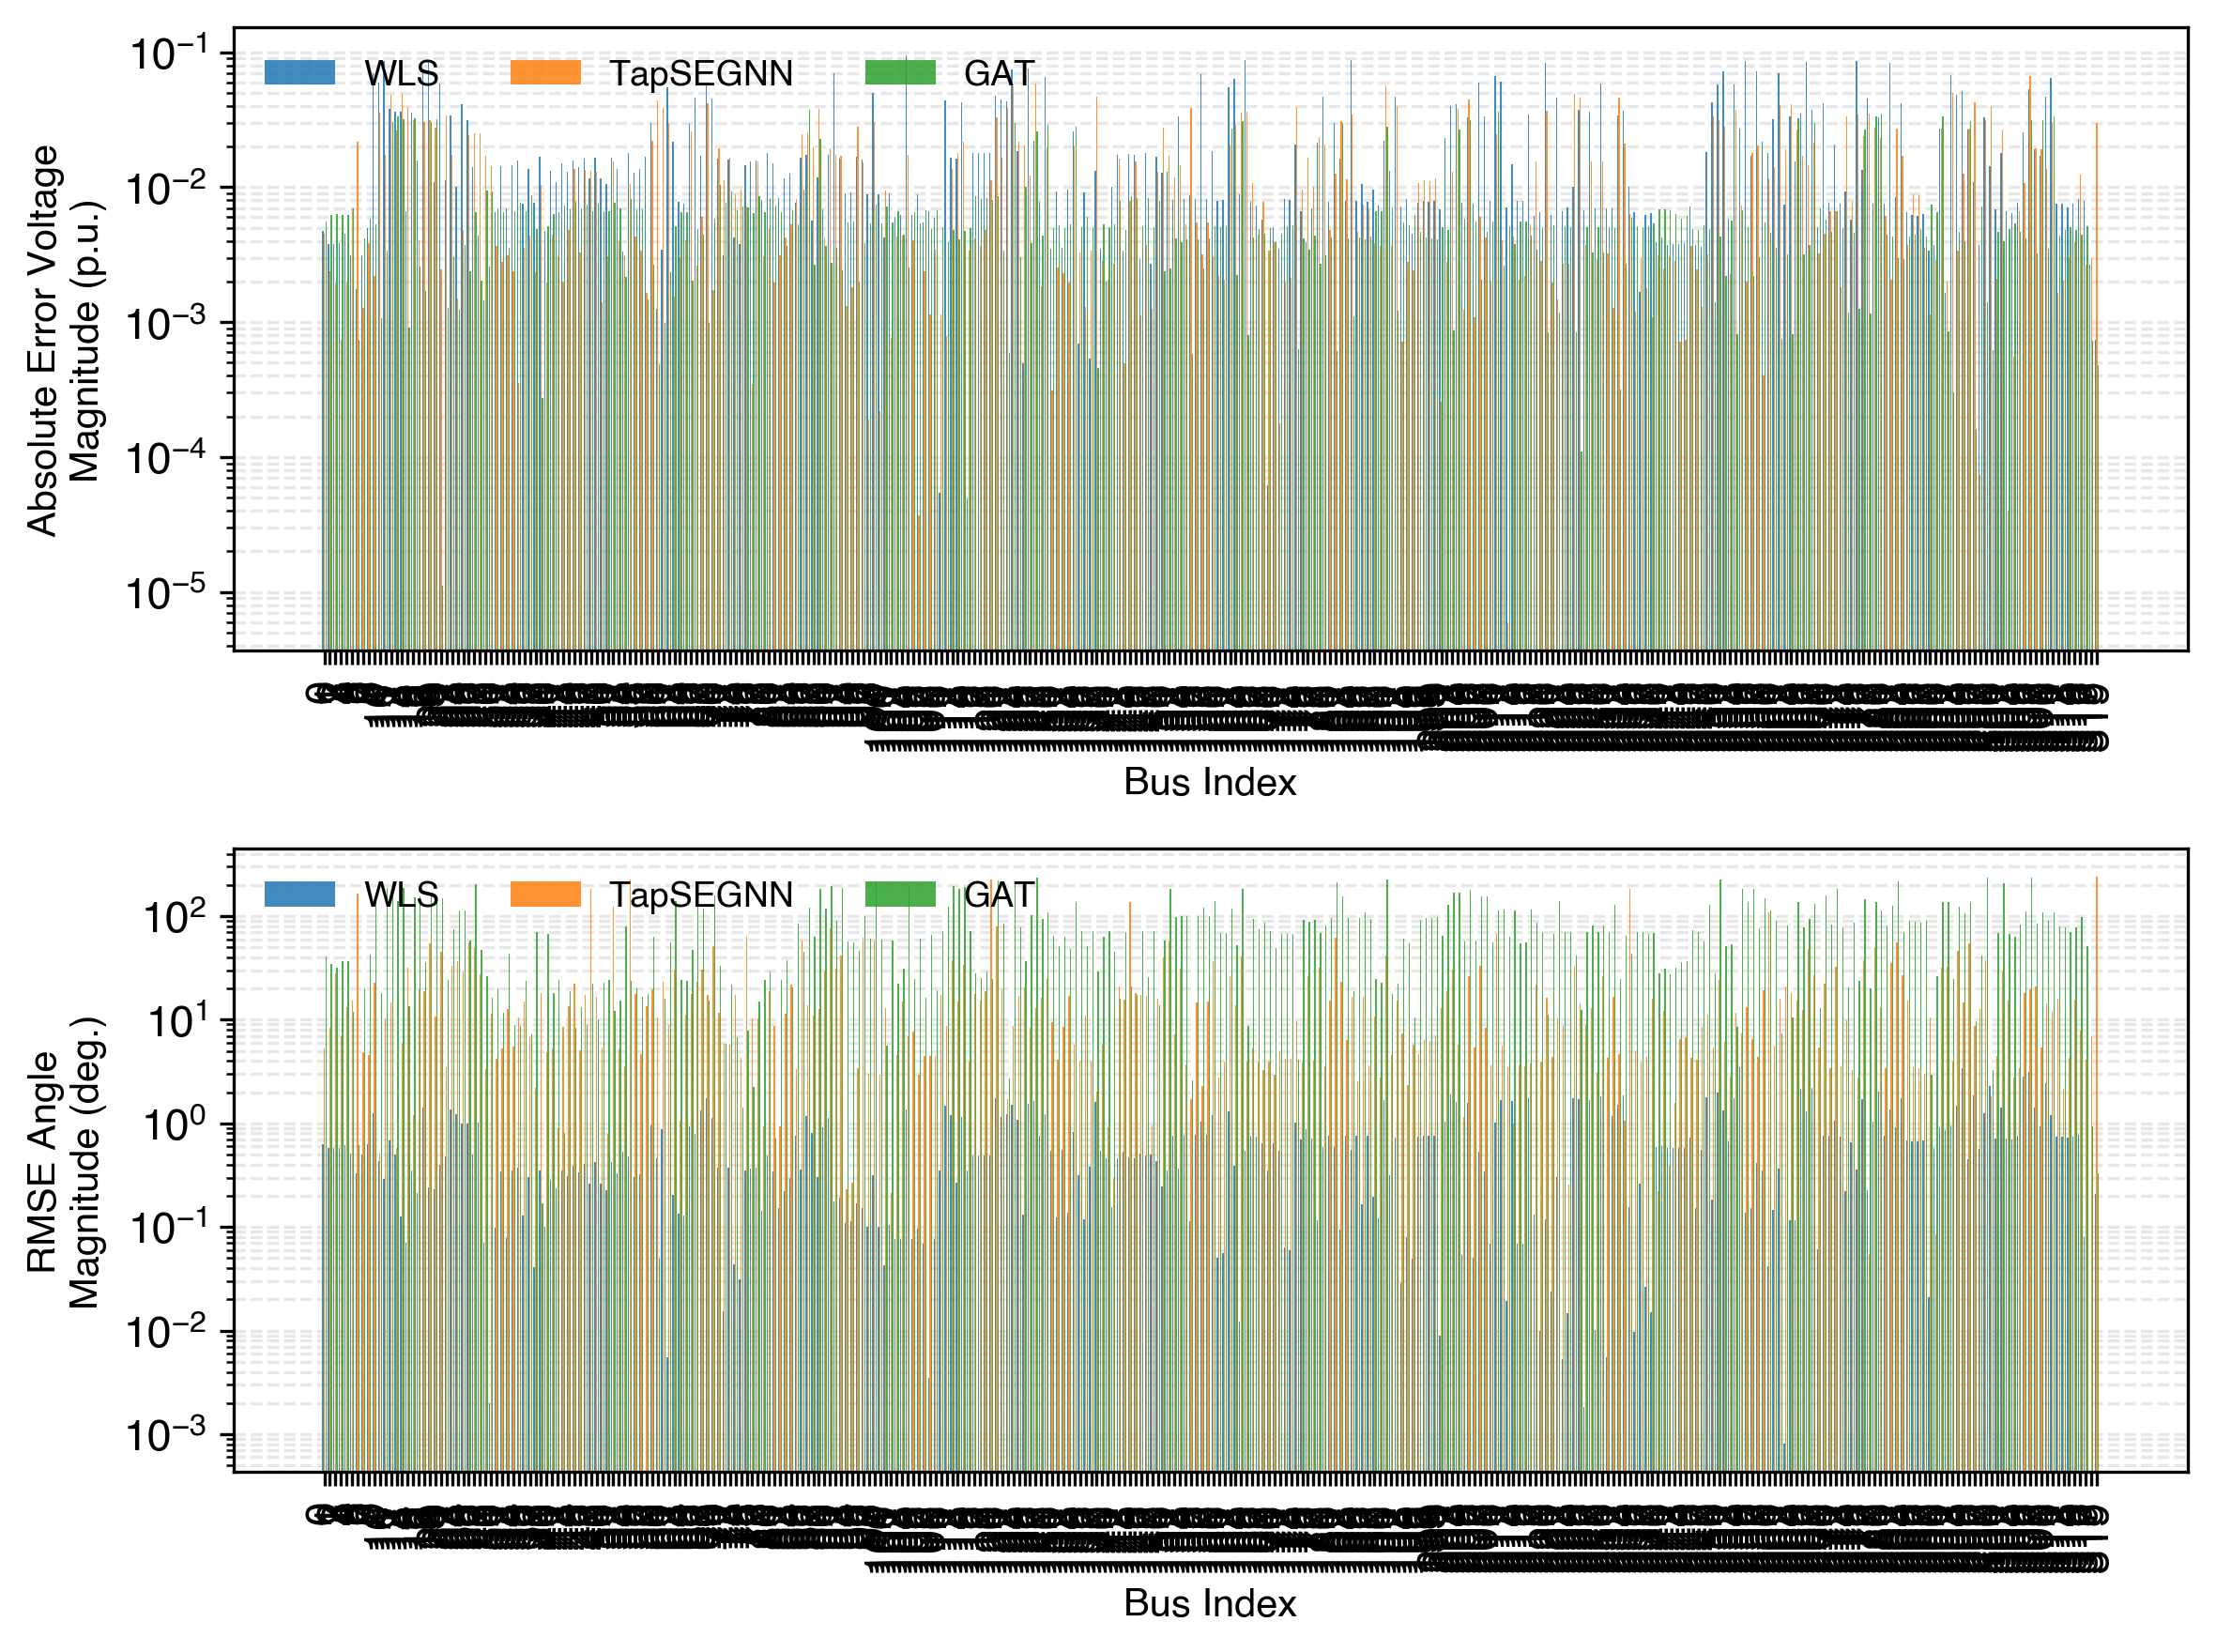

In [13]:
%matplotlib inline
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6))
x = np.arange(len(net.bus))
width = 0.22  # Slightly narrower bars for more spacing
spacing = 0.05  # Additional spacing between bars

# Plot bus-specific voltage RMSE with more distinguishable colors
bars1 = ax[0].bar(x - width - spacing, abs_err_v_wls, width, label='WLS',
                  color='#1f77b4', alpha=0.85, edgecolor='none')  # Blue
bars2 = ax[0].bar(x, abs_err_v_tap, width, label='TapSEGNN',
                  color='#ff7f0e', alpha=0.85, edgecolor='none')  # Orange
bars3 = ax[0].bar(x + width + spacing, abs_err_v_gat, width, label='GAT',
                  color='#2ca02c', alpha=0.85, edgecolor='none')  # Green

ax[0].set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
ax[0].set_ylabel('Absolute Error Voltage\nMagnitude (p.u.)', fontweight='semibold', fontsize=10)
ax[0].set_yscale('log')  # Set logarithmic scale
ax[0].legend(loc='upper left', ncol=3, frameon=False, fontsize=9)
ax[0].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0, which='both')
ax[0].set_axisbelow(True)
ax[0].set_xticks(x)
ax[0].set_xticklabels(x, rotation=90)

# Plot bus-specific angle RMSE with more distinguishable colors
bars1a = ax[1].bar(x - width - spacing, abs_err_a_wls, width, label='WLS',
                   color='#1f77b4', alpha=0.85, edgecolor='none')  # Blue
bars2a = ax[1].bar(x, abs_err_a_tap, width, label='TapSEGNN',
                   color='#ff7f0e', alpha=0.85, edgecolor='none')  # Orange
bars3a = ax[1].bar(x + width + spacing, abs_err_a_gat, width, label='GAT',
                   color='#2ca02c', alpha=0.85, edgecolor='none')  # Green

ax[1].set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
ax[1].set_ylabel('RMSE Angle\nMagnitude (deg.)', fontweight='semibold', fontsize=10)
ax[1].set_yscale('log')  # Set logarithmic scale
ax[1].legend(loc='upper left', ncol=3, frameon=False, fontsize=9)
ax[1].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0, which='both')
ax[1].set_axisbelow(True)
ax[1].set_xticks(x)
ax[1].set_xticks(x)
ax[1].set_xticklabels(x, rotation=90)

plt.tight_layout()
plt.show()

DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.
DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplotlib.ticker:ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01])
DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplotlib.ticker:ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01])
DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplo

DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplotlib.ticker:ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01])
DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplotlib.ticker:ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01])
DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplotlib.ticker:ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e

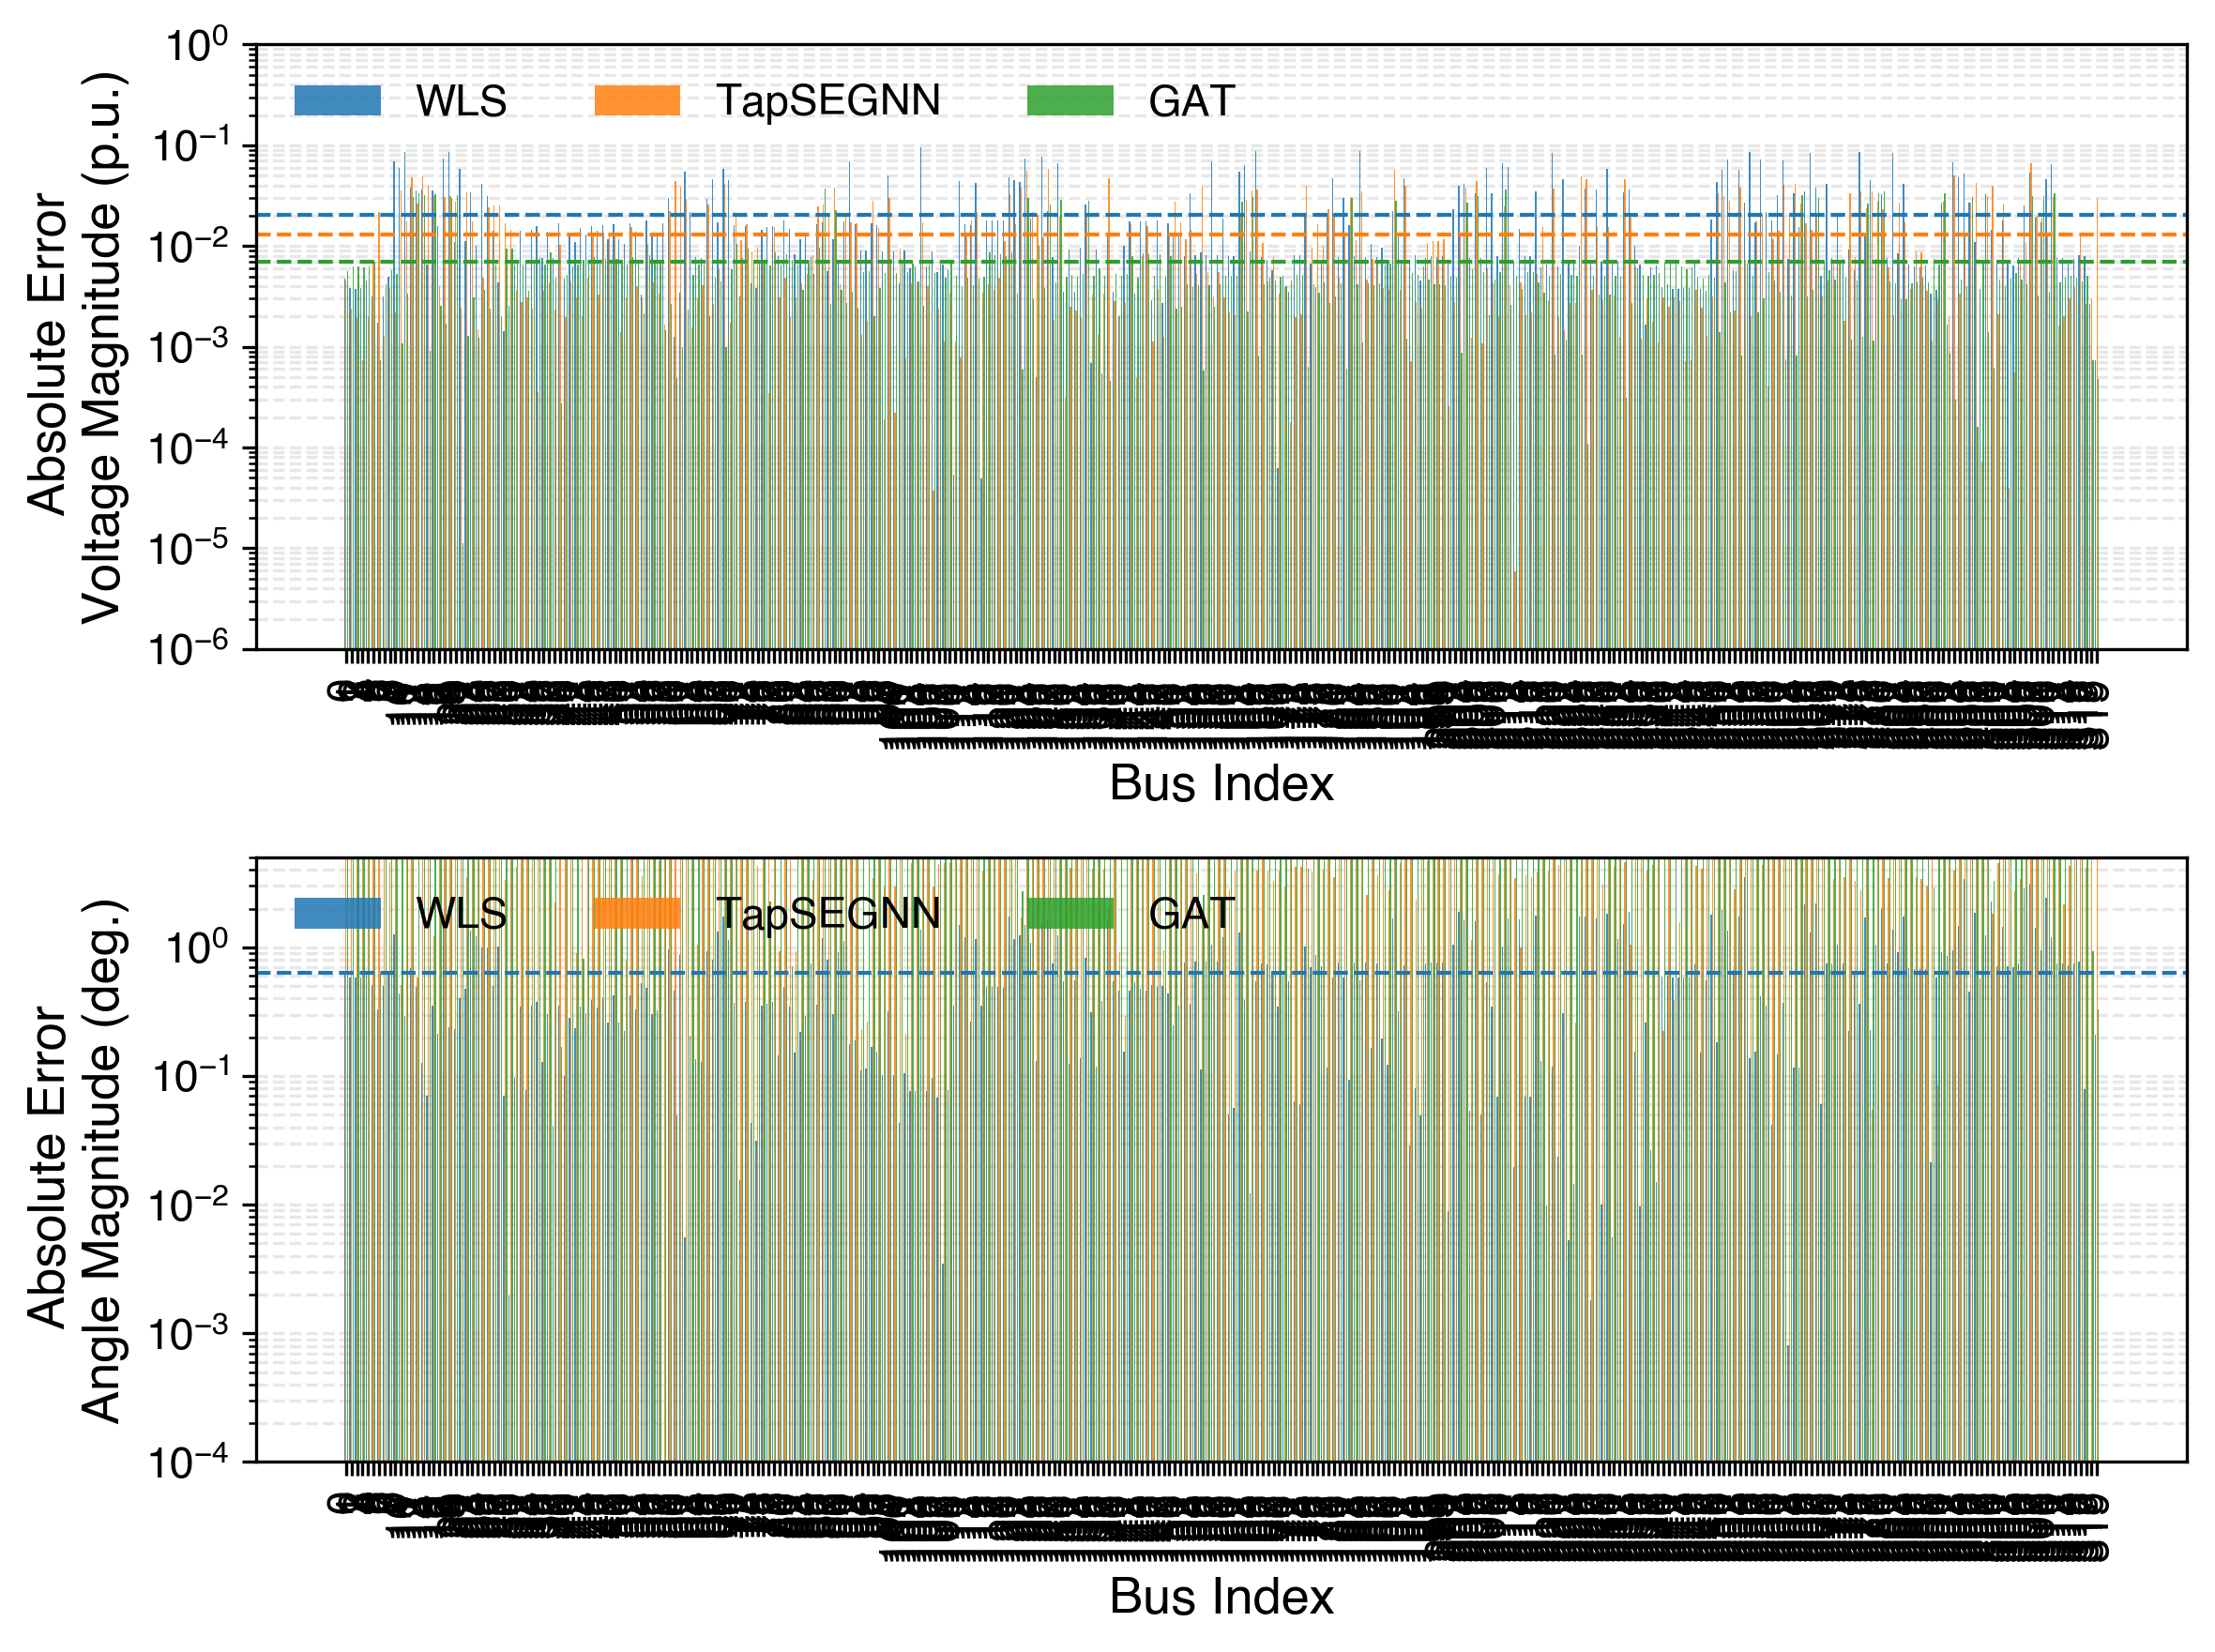

DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplotlib.ticker:ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01])
DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplotlib.ticker:ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01])
DEBUG:matplotlib.ticker:vmin 1e-06 vmax 1.0
DEBUG:matplotlib.ticker:ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e

In [14]:
%matplotlib inline
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

s1, s2, s3 = (50,50,50)
hlw = 1


# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6))
x = np.arange(len(net.bus))
width = 0.22  # Slightly narrower bars for more spacing
spacing = 0.05  # Additional spacing between bars

# Plot bus-specific voltage RMSE with more distinguishable colors
bars1 = ax[0].bar(x - width - spacing, abs_err_v_wls, width, label='WLS',
                  color='#1f77b4', alpha=0.85, edgecolor='none')  # Blue
bars2 = ax[0].bar(x, abs_err_v_tap, width, label='TapSEGNN',
                  color='#ff7f0e', alpha=0.85, edgecolor='none')  # Orange
bars3 = ax[0].bar(x + width + spacing, abs_err_v_gat, width, label='GAT',
                  color='#2ca02c', alpha=0.85, edgecolor='none')  # Green

# # Add horizontal lines for mean RMSE voltage
ax[0].axhline(y=np.mean(abs_err_v_wls), color='#1f77b4', linestyle='--', linewidth=hlw, alpha=1)
ax[0].axhline(y=torch.mean(abs_err_v_tap), color='#ff7f0e', linestyle='--', linewidth=hlw, alpha=1)
ax[0].axhline(y=torch.mean(abs_err_v_gat), color='#2ca02c', linestyle='--', linewidth=hlw, alpha=1)


# Add horizontal markers for mean RMSE voltage
# ax[0].scatter(x, [all_bus_net_rmse_v_wls]*len(x), color='#1f77b4', marker='_', s=s1, linewidths=2, alpha=1, zorder=3)
# ax[0].scatter(x, [all_bus_net_rmse_v_tap*0.95]*len(x), color='#ff7f0e', marker='x', s=s2, linewidths=2, alpha=1, zorder=3)
# ax[0].scatter(x, [all_bus_net_rmse_v_gat]*len(x), color='#2ca02c', marker='+', s=s3, linewidths=2, alpha=1, zorder=3)



# # Add text annotations for voltage RMSE
# ax[0].text(len(x)-0.5, all_bus_net_rmse_v_wls, f'{all_bus_net_rmse_v_wls:.3e}', 
#            color='#1f77b4', fontsize=8, va='bottom', ha='right', fontweight='bold')
# ax[0].text(len(x)-0.5, all_bus_net_rmse_v_tap, f'{all_bus_net_rmse_v_tap:.3e}', 
#            color='#ff7f0e', fontsize=8, va='bottom', ha='right', fontweight='bold')
# ax[0].text(len(x)-0.5, all_bus_net_rmse_v_gat, f'{all_bus_net_rmse_v_gat:.3e}', 
#            color='#2ca02c', fontsize=8, va='bottom', ha='right', fontweight='bold')

ax[0].set_xlabel('Bus Index', fontweight='semibold')
ax[0].set_ylabel('Absolute Error \nVoltage Magnitude (p.u.)', fontweight='semibold')
ax[0].set_ylim([1e-6,1])
ax[0].set_yscale('log')  # Set logarithmic scale
ax[0].legend(loc='upper left', ncol=3, frameon=False)
ax[0].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0, which='both')
ax[0].set_axisbelow(True)
ax[0].set_xticks(x)
ax[0].set_xticklabels(x, rotation=90)

# Plot bus-specific angle RMSE with more distinguishable colors
bars1a = ax[1].bar(x - width - spacing, abs_err_a_wls, width, label='WLS',
                   color='#1f77b4', alpha=0.85, edgecolor='none')  # Blue
bars2a = ax[1].bar(x, abs_err_a_tap, width, label='TapSEGNN',
                   color='#ff7f0e', alpha=0.85, edgecolor='none')  # Orange
bars3a = ax[1].bar(x + width + spacing, abs_err_a_gat, width, label='GAT',
                   color='#2ca02c', alpha=0.85, edgecolor='none')  # Green

# # Add horizontal lines for mean RMSE angle
ax[1].axhline(y=np.mean(abs_err_a_wls), color='#1f77b4', linestyle='--', linewidth=hlw, alpha=1)
ax[1].axhline(y=torch.mean(abs_err_a_tap), color='#ff7f0e', linestyle='--', linewidth=hlw, alpha=1)
ax[1].axhline(y=torch.mean(abs_err_a_gat), color='#2ca02c', linestyle='--', linewidth=hlw, alpha=1)

# Add horizontal markers for mean RMSE angle
# ax[1].scatter(x, [all_bus_net_rmse_a_wls]*len(x), color='#1f77b4', marker='_', s=s1, linewidths=2, alpha=1, zorder=3)
# ax[1].scatter(x, [all_bus_net_rmse_a_tap]*len(x), color='#ff7f0e', marker='x', s=s2, linewidths=2, alpha=1, zorder=3)
# ax[1].scatter(x, [all_bus_net_rmse_a_gat]*len(x), color='#2ca02c', marker='+', s=s3, linewidths=2, alpha=1, zorder=3)

# # Add text annotations for angle RMSE
# ax[1].text(len(x)-0.5, all_bus_net_rmse_a_wls, f'{all_bus_net_rmse_a_wls:.3e}', 
#            color='#1f77b4', fontsize=8, va='bottom', ha='right', fontweight='bold')
# ax[1].text(len(x)-0.5, all_bus_net_rmse_a_tap, f'{all_bus_net_rmse_a_tap:.3e}', 
#            color='#ff7f0e', fontsize=8, va='bottom', ha='right', fontweight='bold')
# ax[1].text(len(x)-0.5, all_bus_net_rmse_a_gat, f'{all_bus_net_rmse_a_gat:.3e}', 
#            color='#2ca02c', fontsize=8, va='bottom', ha='right', fontweight='bold')

ax[1].set_xlabel('Bus Index', fontweight='semibold')
ax[1].set_ylabel('Absolute Error \nAngle Magnitude (deg.)', fontweight='semibold')
ax[1].set_ylim([1e-4,5])
ax[1].set_yscale('log')  # Set logarithmic scale
ax[1].legend(loc='upper left', ncol=3, frameon=False)
ax[1].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0, which='both')
ax[1].set_axisbelow(True)
ax[1].set_xticks(x)
ax[1].set_xticklabels(x, rotation=90)

plt.tight_layout()
plt.show()

fig.savefig('FIG_baselines.pdf', dpi=300, bbox_inches='tight')

In [15]:
print(f"Voltage Angles and Magnitudes RMSE for a single graph\n"
      f"==============================================\n"
      f"WLS RMSE_A:   {all_bus_net_rmse_a_wls:.3e}\n"
      f"GAT RMSE_A:   {all_bus_net_rmse_a_gat:.3e}\n"
      f"TAPSE RMSE_A: {all_bus_net_rmse_a_tap:.3e}\n"
      f"----------------------------------------------\n"
      f"WLS RMSE_V:   {all_bus_net_rmse_v_wls:.3e}\n"
      f"GAT RMSE_V:   {all_bus_net_rmse_v_gat:.3e}\n"
      f"TAPSE RMSE_V: {all_bus_net_rmse_v_tap:.3e}\n"
      f"==============================================\n"
      f"MAE from AE vectors for Voltage Angles and Magnitudes for a single graph\n"
      f"WLS MAE A:    {np.mean(abs_err_a_wls):.3e}\n"
      f"GAT MAE A:    {torch.mean(abs_err_a_gat):.3e}\n"
      f"TAPSE MAE A:  {torch.mean(abs_err_a_tap):.3e}\n"
      f"----------------------------------------------\n"
      f"WLS MAE_V:    {np.mean(abs_err_v_wls):.3e}\n"
      f"GAT MAE V:    {torch.mean(abs_err_v_gat):.3e}\n"
      f"TAPSE MAE V:  {torch.mean(abs_err_v_tap):.3e}\n"
      f"==============================================\n")

Voltage Angles and Magnitudes RMSE for a single graph
WLS RMSE_A:   8.793e-01
GAT RMSE_A:   9.432e+01
TAPSE RMSE_A: 3.667e+01
----------------------------------------------
WLS RMSE_V:   2.961e-02
GAT RMSE_V:   1.053e-02
TAPSE RMSE_V: 1.894e-02
MAE from AE vectors for Voltage Angles and Magnitudes for a single graph
WLS MAE A:    6.390e-01
GAT MAE A:    7.518e+01
TAPSE MAE A:  1.902e+01
----------------------------------------------
WLS MAE_V:    2.050e-02
GAT MAE V:    7.024e-03
TAPSE MAE V:  1.300e-02



In [16]:
torch.mean(abs_err_a_gat)

tensor(75.1848)

In [17]:
# # Set publication-quality style with modern fonts
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
# plt.rcParams['mathtext.fontset'] = 'stixsans'
# plt.rcParams['font.size'] = 11
# plt.rcParams['axes.labelsize'] = 13
# plt.rcParams['axes.titlesize'] = 14
# plt.rcParams['xtick.labelsize'] = 11
# plt.rcParams['ytick.labelsize'] = 11
# plt.rcParams['legend.fontsize'] = 11
# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['axes.labelweight'] = 'normal'
# plt.rcParams['axes.titleweight'] = 'semibold'

# # Create figure with two subplots
# fig, ax = plt.subplots(figsize=(8, 3))
# x = np.arange(len(net.bus))
# width = 0.25

# # Plot bus-specific voltage RMSE
# bars1 = ax.bar(x - width, wls_rmse_v, width, label='WLS',
#                   color='#2E86AB', alpha=0.85, edgecolor='none')
# bars2 = ax.bar(x, tapsegnn_rmse_v, width, label='TapSEGNN',
#                   color='#A23B72', alpha=0.85, edgecolor='none')
# # bars3 = ax.bar(x + width, gat_rmse_v, width, label='GAT',
# #                   color='#F30E34', alpha=0.85, edgecolor='none')

# ax.set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
# ax.set_ylabel('RMSE Voltage\nMagnitude (p.u.)', fontweight='semibold', fontsize=10)
# ax.legend(loc='upper left', ncol=3, frameon=False)
# ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
# ax.set_axisbelow(True)
# ax.set_xticks(x)
# ax.set_xticklabels(x, rotation=90)


# plt.tight_layout()
# plt.show()

# 

In [18]:
# torch.save(model_GAT.state_dict(), parent_dir + "/results/best_GAT.pth")
# torch.save(model.state_dict(), parent_dir + "/results/best_NEGATRegressor.pth")
